In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.DataFrame({
    'name' : ['Rohan','Dnyanu','Radha','Dau','Shiv','Gauri','Shruti'],
    'age' : [20, np.nan, 17, 15, np.nan, 19, 8],
    'standerd' : ['SE', 'HSC', 'HSC', np.nan, '9th', 'FE', '3rd'],
    'marks' : [70, 65, np.nan, 81, 73, 92, np.nan]
})

In [ ]:
df

,name,age,standerd,marks
0,Rohan,20.0,SE,70.0
1,Dnyanu,NaN,HSC,65.0
2,Radha,17.0,HSC,NaN
3,Dau,15.0,NaN,81.0
4,Shiv,NaN,9th,73.0
5,Gauri,19.0,FE,92.0
6,Shruti,8.0,3rd,NaN


In [ ]:
df.isnull().sum()

name        0
age         2
standerd    1
marks       2
dtype: int64

In [ ]:
age_fill = df['age'].fillna(0)
marks_fill = df['marks'].fillna(df['marks'].mean())

In [ ]:
marks_fill

0    70.0
1    65.0
2    76.2
3    81.0
4    73.0
5    92.0
6    76.2
Name: marks, dtype: float64

In [ ]:
df['standerd'].fillna(df['standerd'].mode())

0     SE
1    HSC
2    HSC
3    NaN
4    9th
5     FE
6    3rd
Name: standerd, dtype: object

In [ ]:
df.fillna(method='ffill')

C:\Users\PC\AppData\Local\Temp\ipykernel_14104\1193302488.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill')


,name,age,standerd,marks
0,Rohan,20.0,SE,70.0
1,Dnyanu,20.0,HSC,65.0
2,Radha,17.0,HSC,65.0
3,Dau,15.0,HSC,81.0
4,Shiv,15.0,9th,73.0
5,Gauri,19.0,FE,92.0
6,Shruti,8.0,3rd,92.0


In [ ]:
df.fillna(method='bfill')

C:\Users\PC\AppData\Local\Temp\ipykernel_14104\2831856154.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill')


,name,age,standerd,marks
0,Rohan,20.0,SE,70.0
1,Dnyanu,17.0,HSC,65.0
2,Radha,17.0,HSC,81.0
3,Dau,15.0,9th,81.0
4,Shiv,19.0,9th,73.0
5,Gauri,19.0,FE,92.0
6,Shruti,8.0,3rd,NaN


In [ ]:
def auto_fillna(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median())
            elif df[col].dtype == 'object' :
                df[col].fillna(df[col].mode())

    return df
df_clean = auto_fill(df)
                

In [ ]:
print(df_clean)

     name   age standerd  marks
0   Rohan  20.0       SE   70.0
1  Dnyanu  17.0      HSC   65.0
2   Radha  17.0      HSC   73.0
3     Dau  15.0      HSC   81.0
4    Shiv  17.0      9th   73.0
5   Gauri  19.0       FE   92.0
6  Shruti   8.0      3rd   73.0


In [ ]:
import matplotlib.pyplot as plt

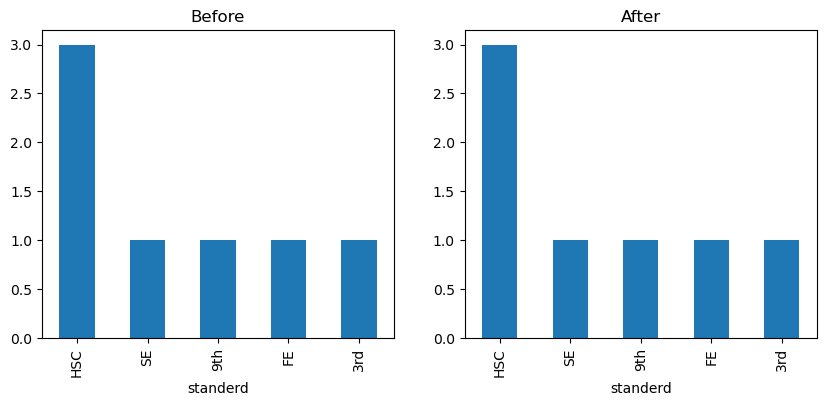

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

df['standerd'].value_counts().plot(kind='bar', ax=ax[0], title='Before')
df_clean['standerd'].value_counts().plot(kind='bar', ax=ax[1], title='After')

plt.show()


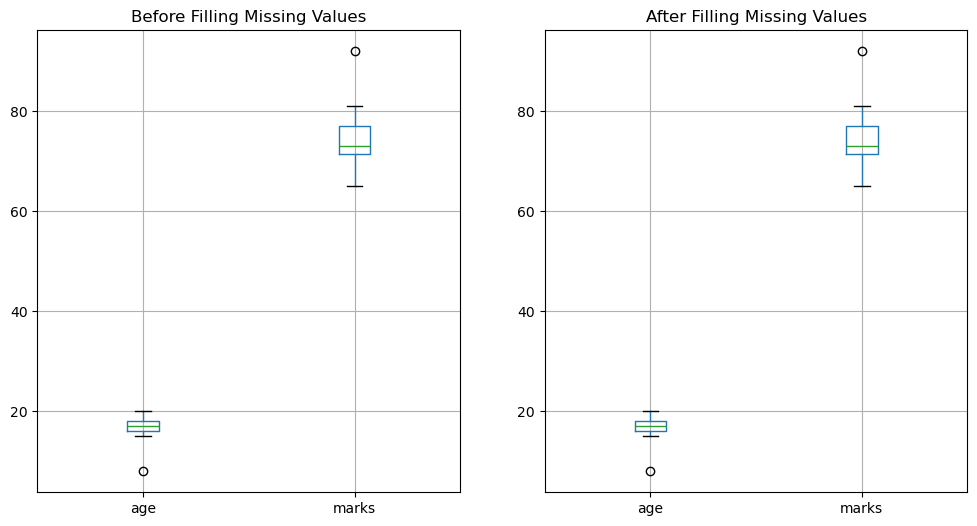

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Before cleaning
df[['age','marks']].boxplot(ax=axes[0])
axes[0].set_title("Before Filling Missing Values")

# After cleaning
df_clean[['age','marks']].boxplot(ax=axes[1])
axes[1].set_title("After Filling Missing Values")

plt.show()

In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
imputer = KNNImputer(n_neighbors=2)
df[['age','marks']] = imputer.fit_transform(df[['age','marks']])

In [ ]:
imputer

KNNImputer(n_neighbors=2)

In [ ]:
df

,name,age,standerd,marks
0,Rohan,20.0,SE,70.0
1,Dnyanu,17.0,HSC,65.0
2,Radha,17.0,HSC,73.0
3,Dau,15.0,HSC,81.0
4,Shiv,17.0,9th,73.0
5,Gauri,19.0,FE,92.0
6,Shruti,8.0,3rd,73.0
